# Laptop Price Prediction — K-Nearest Neighbors Regression

This notebook predicts laptop prices from their specs using **KNN Regression**.

Improvements over the original version:
- Fixed a **data leakage bug** (the scaler was fit on the full dataset before the train/test split; now it's fit on the training set only)
- Replaced `LabelEncoder` on `Brand` with **one-hot encoding**, since brand is a nominal (unordered) category and label-encoding it implies a false ordering
- Added **exploratory data analysis (EDA)** visualizations
- Added **hyperparameter tuning** for `k` using cross-validation, with a plot of error vs. `k`
- Added richer **evaluation metrics** (MAE, RMSE, R²) and diagnostic plots (actual vs. predicted, residuals)
- Cleaned up structure, comments, and removed the leftover empty cell

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Load the data

In [2]:
df = pd.read_csv("Laptop_price.csv")
df.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   str    
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), str(1)
memory usage: 54.8 KB


,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


## 3. Exploratory Data Analysis

Before modeling, let's look at how price relates to the other features.

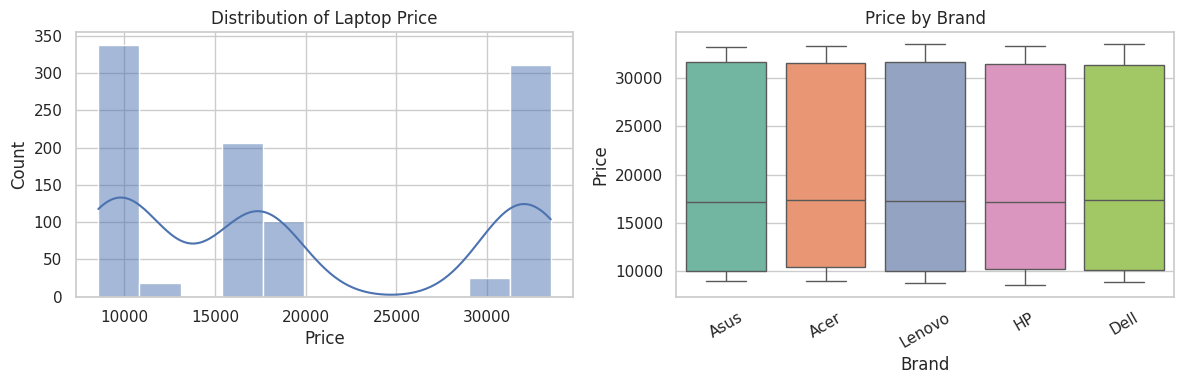

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Price"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Laptop Price")
axes[0].set_xlabel("Price")

sns.boxplot(data=df, x="Brand", y="Price", hue="Brand", ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Price by Brand")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

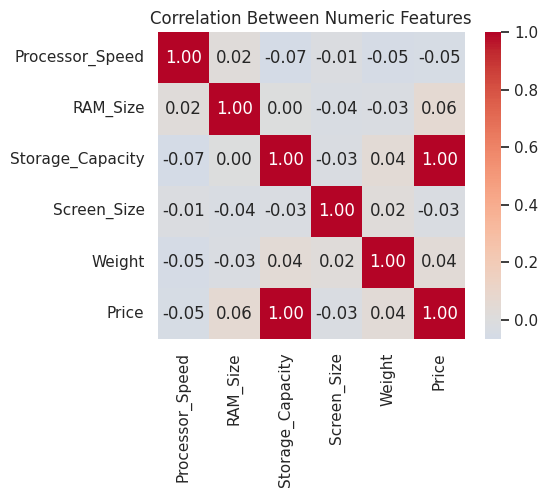

In [5]:
numeric_cols = ["Processor_Speed", "RAM_Size", "Storage_Capacity", "Screen_Size", "Weight", "Price"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

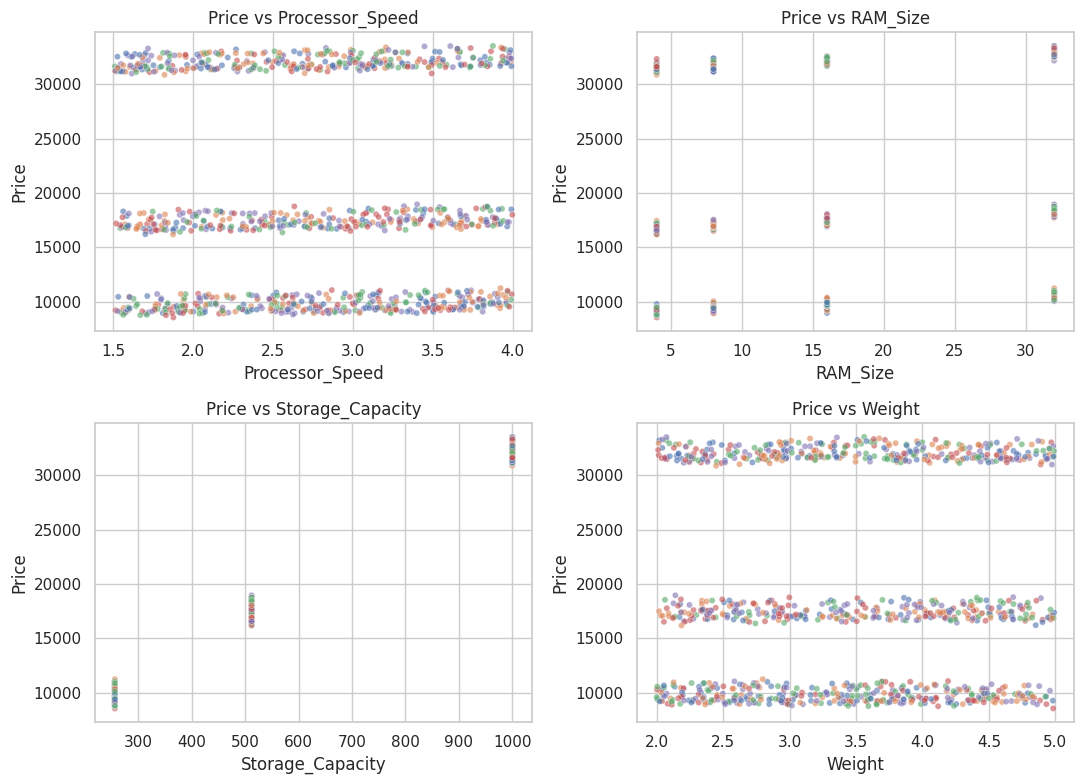

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
feature_pairs = ["Processor_Speed", "RAM_Size", "Storage_Capacity", "Weight"]

for ax, feat in zip(axes.ravel(), feature_pairs):
    sns.scatterplot(data=df, x=feat, y="Price", hue="Brand", ax=ax, s=20, legend=False, alpha=0.6)
    ax.set_title(f"Price vs {feat}")

plt.tight_layout()
plt.show()

## 4. Preprocessing

`Brand` is a nominal category (no natural order), so it's one-hot encoded rather than
label-encoded. The train/test split happens **before** scaling, and the scaler is fit
only on the training data to avoid leaking test-set information into the model.

In [7]:
df_model = pd.get_dummies(df, columns=["Brand"], drop_first=False)

feature_cols = [c for c in df_model.columns if c != "Price"]
X = df_model[feature_cols].values
y = df_model["Price"].values

feature_cols

['Processor_Speed',
 'RAM_Size',
 'Storage_Capacity',
 'Screen_Size',
 'Weight',
 'Brand_Acer',
 'Brand_Asus',
 'Brand_Dell',
 'Brand_HP',
 'Brand_Lenovo']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled = scaler.transform(X_test)          # test data only transformed

print(f"Training samples: {X_train_scaled.shape[0]}, Test samples: {X_test_scaled.shape[0]}")

Training samples: 800, Test samples: 200


## 5. Choosing k with Cross-Validation

Instead of guessing `k` with a heuristic, we test a range of values using 5-fold
cross-validation on the training set and pick the `k` with the lowest RMSE.

In [9]:
k_values = range(1, 41)
cv_rmse = []

for k in k_values:
    knn_k = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn_k, X_train_scaled, y_train, cv=5, scoring="neg_mean_squared_error")
    cv_rmse.append(np.sqrt(-scores.mean()))

best_k = k_values[int(np.argmin(cv_rmse))]
print(f"Best k found: {best_k} (CV RMSE = {min(cv_rmse):.2f})")

Best k found: 2 (CV RMSE = 2702.24)


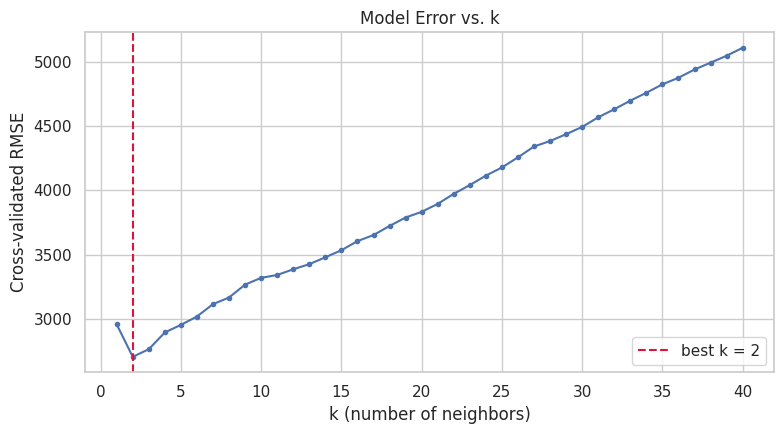

In [10]:
plt.figure(figsize=(8, 4.5))
plt.plot(list(k_values), cv_rmse, marker="o", markersize=3, color="#4C72B0")
plt.axvline(best_k, color="crimson", linestyle="--", label=f"best k = {best_k}")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Cross-validated RMSE")
plt.title("Model Error vs. k")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Train the Final Model

In [11]:
knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## 7. Evaluate on the Test Set

In [12]:
y_pred = knn.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")
print(f"R^2:  {r2:.3f}")

MSE:  4,671,232.39
RMSE: 2,161.30
MAE:  1,129.15
R^2:  0.949


### Actual vs. Predicted Price

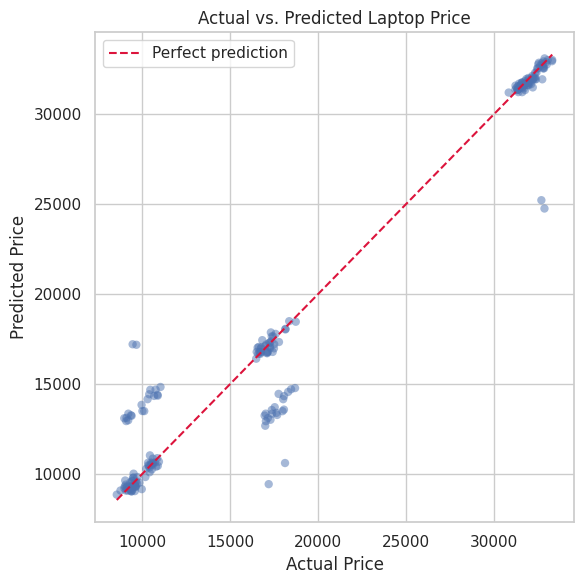

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="#4C72B0", edgecolor="none")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="crimson", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted Laptop Price")
plt.legend()
plt.tight_layout()
plt.show()

### Residual Analysis

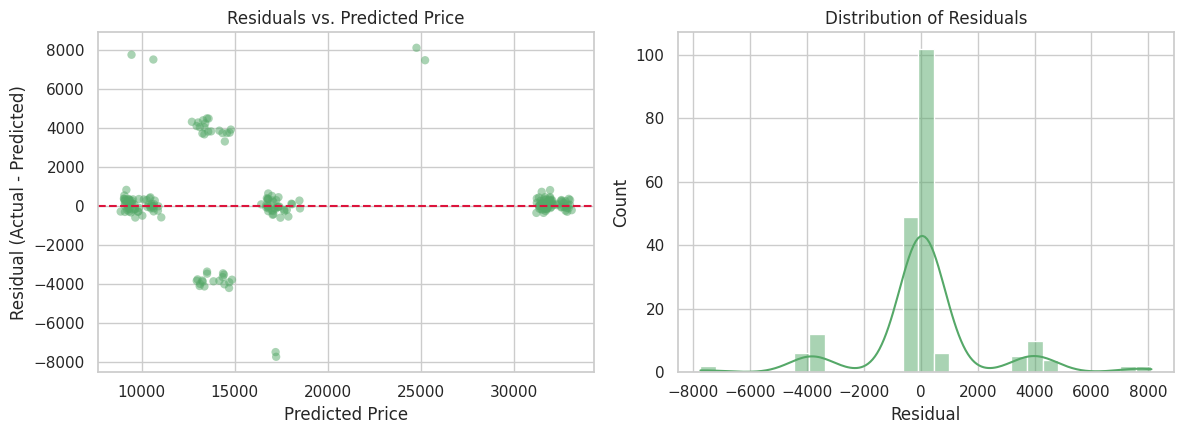

In [14]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_pred, residuals, alpha=0.5, color="#55A868", edgecolor="none")
axes[0].axhline(0, color="crimson", linestyle="--")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs. Predicted Price")

sns.histplot(residuals, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

## 8. Predict the Price of a New Laptop

Example: a Lenovo laptop with the given specs.

In [15]:
new_laptop = pd.DataFrame([{
    "Processor_Speed": 3.241627,
    "RAM_Size": 4,
    "Storage_Capacity": 256,
    "Screen_Size": 11.853023,
    "Weight": 2.029061,
    "Brand": "Lenovo",
}])

# One-hot encode the same way as training data, then align columns
new_laptop_encoded = pd.get_dummies(new_laptop, columns=["Brand"])
new_laptop_encoded = new_laptop_encoded.reindex(columns=feature_cols, fill_value=0)

new_laptop_scaled = scaler.transform(new_laptop_encoded.values)
predicted_price = knn.predict(new_laptop_scaled)

print(f"Predicted Price for the new laptop: {predicted_price[0]:,.2f}")

Predicted Price for the new laptop: 12,950.42
